# Vrednotenje in izbira napovednih modelov

Pri nadzorovanem strojnem učenju ni dovolj, da model dobro opiše učno množico. Glavni cilj je poiskati model, ki bo dobro napovedoval vrednost ciljne spremenljivke tudi na novih primerih, ki niso bili vključeni v učno množico. Izbira modela je zato vedno povezana z vprašanjem, kako dobro model posplošuje in kakšna bo njegova napovedna napaka na novih primerih.

Temeljni kompromis pri izbiri napovednega modela je kompromis med **pristranskostjo** in **varianco**. Zelo enostavni modeli imajo praviloma veliko pristranskost in pogosto **podprilegajo** podatkom (_underfitting_), zelo prilagodljivi modeli pa imajo majhno pristranskost, vendar veliko varianco in se lahko **preprilegajo** učni množici (_overfitting_). Dober model išče ravnotežje med obema skrajnostma.

Za teoretično razumevanje tega kompromisa predpostavimo, da podatke generira pravi model
$$
    Y = m(\boldsymbol{x}) + \varepsilon,
$$
kjer je $m$ pravi deterministični model, $\varepsilon$ pa šum v podatkih s povprečjem $E[\varepsilon] = 0$ in varianco $\sigma_\varepsilon^2 = \operatorname{Var}(\varepsilon)$. Naj bo $\hat{m}_S$ napovedni model, naučen na učni množici $S$. Za kvadratno izgubo lahko pričakovano napovedno napako v točki $\boldsymbol{x}_0$ razcepimo na tri komponente:
$$
    \mathbb{E}_S\left[(Y - \hat{m}_S(\boldsymbol{x}_0))^2 \mid X = \boldsymbol{x}_0\right]
    = \sigma_\varepsilon^2 + \left(m(\boldsymbol{x}_0) - \mathbb{E}_S[\hat{m}_S(\boldsymbol{x}_0)]\right)^2 + \operatorname{Var}_S\left(\hat{m}_S(\boldsymbol{x}_0)\right).
$$

Pri tem je:

- $\sigma_\varepsilon^2$ je komponenta **šuma** in predstavlja neodstranljivi del napake, ki izvira iz merilnega šuma, naključnosti ali neopaženih spremenljivk;
- $\left(m(\boldsymbol{x}_0) - \mathbb{E}_S[\hat{m}_S(\boldsymbol{x}_0)]\right)^2$ je kvadrat **pristranskosti** in meri razliko med povprečno napovedjo naučenih modelov in pravo vrednostjo modela $m$;
- $\operatorname{Var}_S(\hat{m}_S(\boldsymbol{x}_0))$ je **varianca** modela in meri, kako občutljivo se napoved spremeni, če model naučimo na drugi učni množici iz iste porazdelitve.

Visoka pristranskost je značilna za preveč toge in enostavne modele: tak model v povprečju napoveduje narobe, ker je preveč enostaven, da bi zajel pravo odvisnost ciljne spremenljivke od napovednih spremenljivk. Po drugi strani so taki modeli navadno stabilni in se na majhne spremembe v učnih podatkih odzovejo le malo, zato imajo nizko varianco.

Visoka varianca je značilna za zapletene, preveč prilagodljive modele: ti se močno odzivajo na majhne spremembe v učnih podatkih, zato so lahko zelo različni od ene učne množice do druge. Taki modeli se praviloma lahko zelo dobro prilagodijo učnim podatkom, vendar zaradi te občutljivosti pogosto slabše posplošujejo.

```{figure} bias-variance-fits.png
---
name: fig-pristranskost-varianca-kompromis
---
Ponazoritev kompromisa med pristranskostjo in varianco na več učnih množicah. Levo vidimo model z visoko pristranskostjo in nizko varianco, desno pa model z nizko pristranskostjo in visoko varianco.
```

Šuma ne moremo odpraviti z izbiro boljšega algoritma za nadzorovano učenje, lahko pa uravnotežimo prvi dve komponenti. Pri tem moramo najti tako kompleksnost modela, da dobimo ustrezno razmerje med pristranskostjo in varianco. Manjšanje pristranskosti praviloma povečuje varianco, manjšanje variance pa povečuje pristranskost.

```{figure} bias-variance-decomposition.png
---
name: fig-pristranskost-varianca-tarca
---
Dekompozicija pričakovane napovedne napake na šum, pristranskost in varianco ter posledični kompromis pri izbiri kompleksnosti modela.
```

Slika {ref}`fig-pristranskost-varianca-tarca` pokaže tipičen potek tega kompromisa: pri majhni kompleksnosti modela prevladuje visoka pristranskost, pri veliki kompleksnosti pa visoka varianca. Le vmesno območje ponuja dober kompromis. Zato pri izbiri modela ne primerjamo le različnih algoritmov, temveč tudi njihove nastavitve, na primer globino drevesa, število sosedov pri metodi k-NN ali stopnjo regularizacije.

## Vrednotenje napovedne zmogljivosti modela

Napovedno zmogljivost modela moramo vedno ocenjevati na podatkih, ki jih model med učenjem ni videl. Če napako merimo samo na učni množici, dobimo predvsem oceno, kako dobro si je model zapomnil učne primere, ne pa kako dobro bo deloval v praksi, ko bo obravnaval primere izven učne množice. Zato razlikujemo med **učno napako** in **testno napako**.

Naj bo $L \colon D_Y \times D_Y \to \mathbb{R}_{\ge 0}$ funkcija izgube. Za model $m$ in podatkovno množico $S$ lahko učno napako zapišemo kot
$$
    \mathrm{Error}_{\mathrm{train}}(m, S) = \frac{1}{|S|} \sum_{\langle \boldsymbol{x}, y \rangle \in S} L(y, m(\boldsymbol{x})).
$$
Ta ocena je navadno optimistična, saj jo merimo na primerih, ki so bili uporabljeni za učenje modela. Testna napaka pa opisuje napako na primerih, ki niso bili uporabljeni pri učenju, torej na primerih izven učne množice. Prav testna napaka nas zanima pri ocenjevanju splošnosti modela.

Najpreprostejši praktični pristop je delitev razpoložljive množice $S$ na **učno** in **testno** množico. Izberemo podmnožico $S_{\mathrm{test}} \subset S$ in definiramo
$$
    S_{\mathrm{train}} = S \setminus S_{\mathrm{test}}, \qquad S_{\mathrm{train}} \cap S_{\mathrm{test}} = \emptyset.
$$
Če delež testnih primerov označimo z $d$, velja
$$
    d = \frac{|S_{\mathrm{test}}|}{|S|}.
$$
Na množici $S_{\mathrm{train}}$ naučimo model, na množici $S_{\mathrm{test}}$ pa ocenimo njegovo napako. Tak pristop je preprost in hiter, vendar je ocena lahko precej odvisna od konkretnega naključnega razreza primerov iz podatkovne množice $S$. Če pri delitvi slučajno dobimo lažjo ali težjo testno množico, se lahko ocena opazno spremeni.

Zato pogosto uporabimo metodo, ki jo imenujemo **prečno preverjanje** (angl. _cross-validation_). Množico $S$ razdelimo na $k$ približno enako velikih, paroma disjunktnih podmnožic
$$
    S = \bigcup_{i=1}^{k} S_i, \qquad \forall i \ne j : S_i \cap S_j = \emptyset, \qquad |S_i| \approx |S_j|.
$$
Za vsak $i = 1, 2, \dots, k$ definiramo
$$
    S_{\mathrm{train}, i} = S \setminus S_i, \qquad S_{\mathrm{test}, i} = S_i,
$$
na množici $S_{\mathrm{train}, i}$ naučimo model $m_i$, nato pa na množici $S_i$ izmerimo njegovo napako. Končna ocena napake pri $k$-kratnem prečnem preverjanju je
$$
    \mathrm{Error}_{\mathrm{CV}}(S) = \frac{1}{k} \sum_{i=1}^{k} \mathrm{Error}(m_i, S_i).
$$
Tako praviloma dobimo stabilnejšo in manj naključno oceno splošnosti modela kot pri enem razrezu na učno in testno množico.

Pri klasifikaciji moramo biti posebej pozorni na **stratifikacijo** pri naključnem vzorčenju primerov. To pomeni, da pri delitvi na podmnožice ohranjamo približno enako porazdelitev vrednosti ciljne spremenljivke, kot jo ima celotna množica $S$. Brez stratifikacije lahko pri neuravnoteženih podatkih dobimo testne podmnožice, kjer se določena vrednost ciljne spremenljivke sploh ne pojavi, s tem pa postane ocena zmogljivosti zelo nezanesljiva.

Razliko med enkratnim razrezom na učno in testno množico ter prečnim preverjanjem si poglejmo še na kratkem primeru, kjer isti klasifikacijski model 50 krat ocenimo na dva načina. Najprej z več naključnimi stratificiranimi delitvami na učno in testno množico. Nato pa še s ponovljenim stratificiranim 5-kratnim prečnim preverjanjem. Tako dobimo dve porazdelitvi ocen, ki ju lahko neposredno primerjamo.

Povprečna točnost pri naključnih delitvah: 0.956
Standardni odklon pri naključnih delitvah: 0.027
Povprečna točnost pri 5-kratnem PP: 0.956
Standardni odklon pri 5-kratnem PP: 0.008


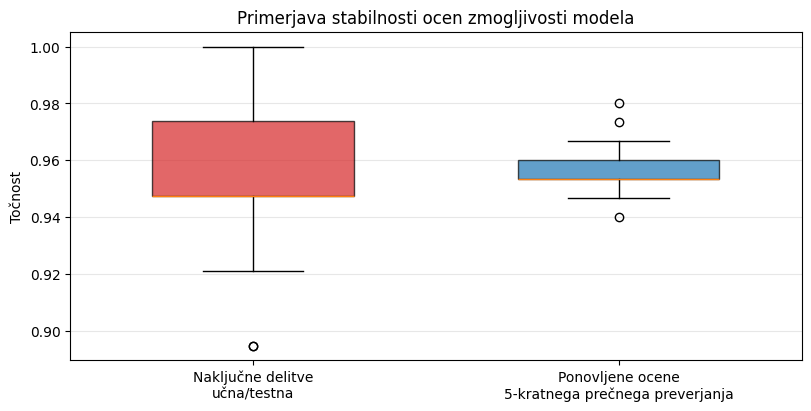

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


iris = load_iris()
X, y = iris.data, iris.target

# Model zgradimo kot cevovod, ki najprej standardizira podatke
# Nato pa uporabimo metodo najbližjih sosedov z nastavitvijo 10 sosedov
model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=10))

# 50 krat ocenimo točnost modela z naključno delitvijo na ucno in testno mnozico
ocene_ut  = []
ocene_pp = []
for random_state in range(50):
    # Najprej opravimo naključno delitev na učno in testno mnozico
    # Pri čemer opravimo stratifikacijo glede na ciljno spremenljivko
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.25,
        stratify=y,
        random_state=random_state,
    )
    model.fit(X_train, y_train)
    ocene_ut.append(model.score(X_test, y_test))

    # Za primerjavo ocenimo model tudi z uporabo5-kratnega prečnega preverjanja
    pp = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    ocene_pp.append(cross_val_score(model, X, y, cv=pp).mean())

ocene_ut = np.array(ocene_ut)
ocene_pp = np.array(ocene_pp)

print(f'Povprečna točnost pri naključnih delitvah: {ocene_ut.mean():.3f}')
print(f'Standardni odklon pri naključnih delitvah: {ocene_ut.std():.3f}')
print(f'Povprečna točnost pri 5-kratnem PP: {ocene_pp.mean():.3f}')
print(f'Standardni odklon pri 5-kratnem PP: {ocene_pp.std():.3f}')

plot, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
box = ax.boxplot(
    [ocene_ut, ocene_pp],
    tick_labels=['Naključne delitve\nučna/testna', 'Ponovljene ocene\n5-kratnega prečnega preverjanja'],
    patch_artist=True,
    widths=0.55
)
for patch, color in zip(box['boxes'], ['tab:red', 'tab:blue']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Primerjava stabilnosti ocen zmogljivosti modela')
ax.set_ylabel('Točnost')
ax.grid(axis='y', alpha=0.3)

plt.show()

Škatli na zgornjem grafu vizualizirata primerjavo porazdelitev ocen, ki jih dobimo pri več različnih naključnih delitvah na učno in testno množico, s porazdelitvijo ocen pri ponovljenem 5-kratnem prečnem preverjanju. Pri naključnih delitvah je razpon ocen večji, ker se lahko posamezna ocena opazno spremeni že zato, ker v testno množico po naključju pride nekoliko lažji ali težji nabor primerov.

Ker pri prečnem preverjanju vsak primer enkrat nastopi v testni in večkrat v učni vlogi, je končna ocena običajno manj občutljiva na konkreten razrez podatkov in zato stabilnejša. To se pokaže tudi v manjšem standardnem odklonu ocen. Prav zato prečno preverjanje navadno uporabimo pri izbiri modela in njegovih parametrov: izberemo več algoritmov oziroma več nastavitev istega algoritma, za vsako kombinacijo ocenimo napako s prečnim preverjanjem, nato pa izberemo tisto, ki doseže najmanjšo oceno testne napake. Šele nato na celotni razpoložljivi učni množici zgradimo končni model.

## Običajne mere zmogljivosti

Izbira mere zmogljivosti je odvisna od tipa problema in od tega, kakšne napake želimo kaznovati.

### Mere za regresijo

Pri regresiji napovedujemo numerične vrednosti, zato nas zanima velikost odstopanja med napovedjo $\hat{y}$ in opazovano vrednostjo $y$. Spodaj je nekaj standardnih mer, ki jih pri tem uporabljamo

- Povprečna kvadratna napaka (angl. _mean squared error, MSE_):
$$
    \mathrm{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2.
$$
  Večje napake kaznuje močneje kot manjše.

- Koren povprečne kvadratne napake (_root mean squared error, RMSE_), imenujemo jo tudi celotna napaka:
$$
    \mathrm{RMSE} = \sqrt{\mathrm{MSE}}.
$$
  Uporaben je, ker je izražen v istih enotah kot ciljna spremenljivka.

- Povprečna absolutna napaka (angl. _mean absolute error, MAE_):
$$
    \mathrm{MAE} = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|.
$$
  Je manj občutljiva mera na osamelce (ekstremne vrednosti) kot povprečna kvadratna napaka, saj večjih napak ne kaznuje močneje kot manjše. Pa še izražena je v istih enotah kot ciljna spremenljivka.

- Relativna celotna napaka (_relative RMSE, ReRMSE_) primerja koren povprečne kvadratne napake modela z isto napako trivialnega modela, ki vedno napove povprečno vrednost ciljne spremenljivke. Formalno ga zapišemo kot
$$
    \mathrm{ReRMSE} = \sqrt{\frac{\sum_{\langle \boldsymbol{x}, y \rangle \in S} (y - \hat{y})^2}{\sum_{\langle \boldsymbol{x}, y \rangle \in S} (y - \bar{y})^2}},
$$
  kjer je $\bar{y}$ povprečna vrednost ciljne spremenljivke v (učni) množici $S$. Vrednost $1$ pomeni, da je model enako dober kot trivialni model s konstantno napovedjo povprečja, manjše vrednosti pa pomenijo boljši model.

- Pojasnjena varianca (angl. _explained variance_) meri, kolikšen delež variance ciljne spremenljivke pojasni model. Pogosto jo zapišemo kot
$$
    \mathrm{EV} = 1 - \frac{\operatorname{Var}(Y - \hat{Y})}{\operatorname{Var}(Y)}.
$$
  Večja vrednost pomeni boljši model; vrednost $1$ pomeni popolno prileganje. Sorodna mera brez začetnega odštevanja, $\operatorname{Var}(Y - \hat{Y}) / \operatorname{Var}(Y)$, meri delež **nepojasnjene** variance in jo zato želimo minimizirati.

### Mere za klasifikacijo

Pri klasifikaciji nas pogosto najprej zanimata dve osnovni meri.

- Klasifikacijska napaka (angl. _classification error_):
$$
    \mathrm{Error} = \frac{\#\{i : y_i \neq \hat{y}_i\}}{n},
$$
- Klasifikacijska točnost (angl. _accuracy_):
$$
    \mathrm{Accuracy} = \frac{\#\{i : y_i = \hat{y}_i\}}{n} = 1 - \mathrm{Error}.
$$

Pri tem očitno velja $\mathrm{Error} + \mathrm{Accuracy} = 1$.

Točnost je intuitivna, vendar je lahko zavajajoča pri neuravnoteženi porazdelitvi vrednosti ciljne spremenljivke. Če je pozitivnih primerov zelo malo, lahko model doseže visoko točnost že s tem, da skoraj vedno napove večinsko vrednost ciljne spremenljivke, v tem primeru torej vse primere klasificira kot negativne. Zato, da se izognemo takim situacijam potrebujemo bolj podrobne in bolj občutljive mere, ki ločijo med različnimi tipi napak. Takim meram se posvetimo v naslednjem razdelku.

Enostavni primer kode spodaj ponazori uporabo funkcij paketa `scikit-learn` za izračun vrednosti različnih mer zmogljivosti regresijskih in klasifikacijskih napovednih modelov.

In [7]:
from sklearn.metrics import (
    accuracy_score,
    explained_variance_score,
    mean_absolute_error,
    mean_squared_error,
)


# Kratek ilustrativen primer za regresijske mere.
y_true_reg = np.array([3.0, 2.5, 4.1, 5.0, 6.2])
y_pred_reg = np.array([2.8, 2.9, 3.7, 4.8, 6.5])

mse = mean_squared_error(y_true_reg, y_pred_reg)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_reg, y_pred_reg)
baseline = np.full_like(y_true_reg, y_true_reg.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_true_reg, baseline))
relative_rmse = rmse / baseline_rmse
explained_var = explained_variance_score(y_true_reg, y_pred_reg)

print('Regresija')
print(f'  MSE: {mse:.3f}')
print(f'  RMSE: {rmse:.3f}')
print(f'  MAE: {mae:.3f}')
print(f'  Relative RMSE: {relative_rmse:.3f}')
print(f'  Variance explained: {explained_var:.3f}')

# Kratek ilustrativen primer za klasifikacijske mere.
y_true_cls = np.array([0, 1, 1, 0, 1, 0, 1, 1])
y_pred_cls = np.array([0, 1, 0, 0, 1, 0, 1, 0])

accuracy = accuracy_score(y_true_cls, y_pred_cls)
error = 1 - accuracy

print('\nKlasifikacija')
print(f'  Napaka: {error:.3f}')
print(f'  Tocnost: {accuracy:.3f}')

Regresija
  MSE: 0.098
  RMSE: 0.313
  MAE: 0.300
  Relative RMSE: 0.234
  Variance explained: 0.946

Klasifikacija
  Napaka: 0.250
  Tocnost: 0.750


## Matrika napak in ROC

Pri **dvojiški klasifikaciji**, torej takrat, ko za domeno ciljne spremenljivke velja $|D_Y| = 2$ nas pogosto ne zanima zgolj skupno število pravilnih in napačnih napovedi, temveč tudi, *katere vrste napak* model dela. Običajna napaka pri izgubi $0$-$1$,
$$
    \mathrm{Error}(m, S) = \frac{1}{|S|} \sum_{\langle \boldsymbol{x}, y \rangle \in S} L_{01}(y, m(\boldsymbol{x})),
$$
teh razlik ne zazna, zato uvedemo **matriko napak** (_confusion matrix_):

$$
\begin{array}{c|cc}
y \backslash \hat{y} & \oplus & \ominus \\
\hline
\oplus & TP & FN \\
\ominus & FP & TN
\end{array}
$$

Pri tem je $TP$ (angl. _true positives_) število pravilno napovedanih pozitivnih primerov, $TN$ (angl. _true negatives_) število pravilno napovedanih negativnih primerov, $FP$ (angl. _false positives_) število lažno pozitivnih primerov, $FN$ (anlg. _false negatives_) pa število lažno negativnih primerov.

Iz teh štirih števil lahko izpeljemo več pomembnih mer, ki so, za razliko od navadne klasifikacijske napake, občutljive na tip napake, ki jo naredi model (ali gre torej za lažno pozitivne ali lažno negativne primere).

- Delež pravilno razvrščenih pozitivnih primerov, tudi **občutljivost** oziroma priklic (angl. _true positive rate, TPR, recall_)
$$
  \mathrm{TPR} = \frac{TP}{TP + FN},
$$
  To je pravzaprav točnost v množici _pozitivnih_ primerov, torej večja vrednost je boljša.
- Delež pravilno razvrščenih pozitivnih primerov, tudi **specifičnost** (angl. _true negative rate, TNR, specificity_)
$$
  \mathrm{Specificity} = \frac{TN}{TN + FP},
$$
  Podobno je to pravzaprav točnost v množici _negativnih_ primerov, torej večja vrednost je boljša.
- Delež napačno razvrščenih negativnih primerov (angl. _false positive rate, FPR_)
$$
    \mathrm{FPR} = \frac{FP}{FP + TN} = 1 - \mathrm{Specificity}.
$$

Pogosto uporabimo še dve dodatni meri:

- **preciznost** (_precision, positive predictive value, PPV_)
$$
    \mathrm{PPV} = \frac{TP}{TP + FP},
$$
- **mera F** kot harmonična sredina preciznosti in priklica
$$
    F = 2 \cdot \frac{\mathrm{PPV} \cdot \mathrm{TPR}}{\mathrm{PPV} + \mathrm{TPR}}.
$$

Izbira modela je tu pogosto odvisna od tega, katera napaka (lažni pozitivni ali lažni negativni primeri) je dražja. Pri medicinski diagnostiki so lahko posebej problematični lažni negativni primeri, saj spregledamo bolezen. Pri zaznavanju neželene pošte pa so lahko bolj moteči lažni pozitivni primeri, ker med nezaželeno pošto pomotoma uvrstimo legitimna sporočila. Enako točni modeli so zato lahko v praksi zelo različno uporabni.

Pri tem je zelo pomembno, da modeli za dvojiško klasifikacijo pogosto ne vračajo le končne odločitve, temveč tudi **oceno verjetnosti** ali **točkovni rezultat**. Če model napoveduje verjetnost pozitivnega razreda,
$$
    m(\boldsymbol{x}) = P(Y = 1 \mid X = \boldsymbol{x}),
$$
potrebujemo še **prag odločitve** $\tau \in [0, 1]$, s katerim definiramo končno klasifikacijo
$$
    \hat{Y}^{\tau} = \mathbf{1}(m(\boldsymbol{x}) \ge \tau).
$$
Če spreminjamo prag $\tau$, dobimo različna para vrednosti $(\mathrm{FPR}, \mathrm{TPR})$. Krivulja, ki povezuje te točke, je **krivulja ROC** (angl. _receiver operating characteristic_). Boljši modeli imajo krivuljo bliže zgornjemu levemu kotu prostora ROC.

Za primerjavo modelov pogosto uporabimo tudi ploščino pod krivuljo ROC (_area under the curve, AUC_):
$$
    \mathrm{AUC}(m) = \int_0^1 \mathrm{TPR}(m_{\tau}) \, d\,\mathrm{FPR}(m_{\tau}).
$$
Velja naslednja intuitivna interpretacija:
$$
    \mathrm{AUC}(m) = P\bigl(m(\boldsymbol{x}^+) > m(\boldsymbol{x}^-)\bigr),
$$
kjer sta $\langle \boldsymbol{x}^+, 1 \rangle$ in $\langle \boldsymbol{x}^-, 0 \rangle$ naključno izbran pozitiven in negativen primer. Vrednost $1$ pomeni idealen model, vrednost $0.5$ pa model, ki ni boljši od naključnega ugibanja. Kljub temu AUC ni vedno dovolj za končno izbiro modela, saj včasih pomemben le ozek del ROC prostora, na primer območje zelo majhnega izpada $\mathrm{FPR}$.

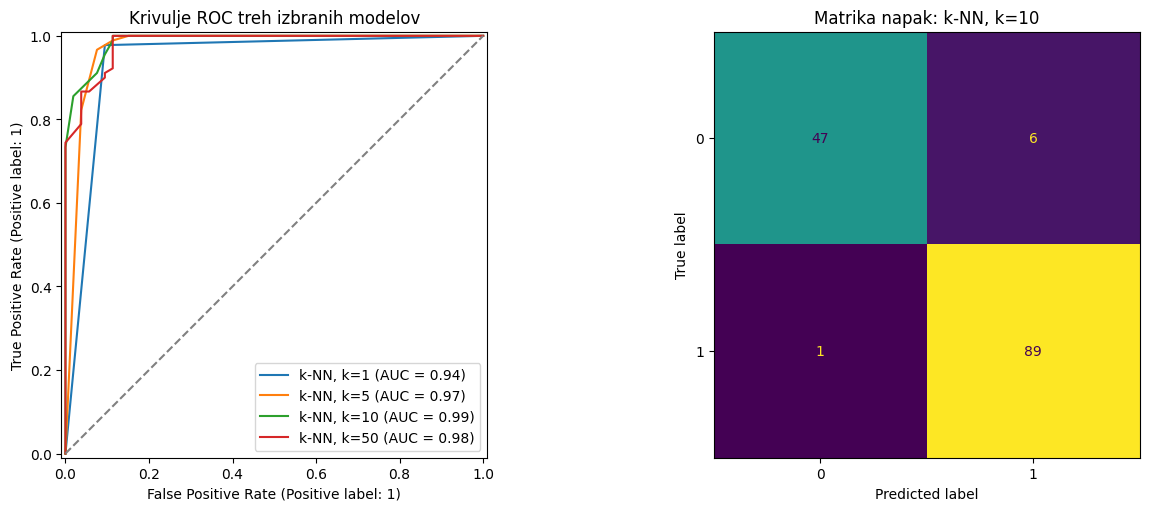

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
from sklearn.neighbors import KNeighborsClassifier


cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=0,
)

models = {
    'k-NN, k=1': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=1)),
    'k-NN, k=5': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    'k-NN, k=10': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=10)),
    'k-NN, k=50': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=50))
}

plot, osi = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

for id, model in models.items():
    model.fit(X_train, y_train)
    y_score = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_score)
    RocCurveDisplay.from_predictions(y_test, y_score, name=f'{id}', ax=osi[0])

naj_model_id = 'k-NN, k=10'
naj_model = models[naj_model_id]
y_pred = naj_model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=osi[1], colorbar=False)

osi[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
osi[0].set_title('Krivulje ROC treh izbranih modelov')
osi[1].set_title(f'Matrika napak: {naj_model_id}')

plt.show()

# Naloga za bonus točke

1. (5 točk, rok za oddajo: 28. april) Izberi podatkovno množico za binarno klasifikacijo in primerjaj vsaj tri različne modele. Za vsak model oceni zmogljivost s stratificiranim prečnim preverjanjem, nato pa na ločeni testni množici prikaži matriko napak in ROC krivuljo. V kratkem komentarju pojasni, kateri model bi izbral_a in zakaj.
<br/><br/>
